# Weather Temperature Forecasting

A weather monitoring station in Jena, Germany has been recording hourly weather data since 2012. Build a forecasting system that predicts the **next hour's temperature** using the past 24 hours of weather data.

---

**Tasks:**

1. **Load Data:** Load the datasets, drop the `datetime` column
2. **Scale Features:** Normalize features to 0-1 range (fit on train only)
3. **Create Sequences:** Use the provided `create_sequences` function with `WINDOW_SIZE = 24`
4. **Build and Train LSTM Model:** Train an LSTM model on the sequences
5. **Build and Train GRU Model:** Train a GRU model on the sequences
6. **Predict:** Generate predictions and inverse-transform back to degree Celsius


---

**Expected Variables:**

| Variable | Description |
|----------|-------------|
| `lstm_predictions` | LSTM predicted temperatures on test data (in degree Celsius, not scaled) |
| `gru_predictions` | GRU predicted temperatures on test data (in degree Celsius, not scaled) |



In [2]:
# Run this cell before writing your solution

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

train_df = pd.read_csv('https://s3.ap-south-1.amazonaws.com/new-assets.ccbp.in/frontend/content/aiml/classical-ml/weather_train.csv')
test_df = pd.read_csv('https://s3.ap-south-1.amazonaws.com/new-assets.ccbp.in/frontend/content/aiml/classical-ml/weather_test.csv')

WINDOW_SIZE = 24

# Converts flat rows into sequences for LSTM/GRU
# Each sample: 24 consecutive hours as input, next hour's temperature as target
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size, 0])  # 0 = temperature column
    return np.array(X), np.array(y)

print(f'Train: {train_df.shape}')
print(f'Test: {test_df.shape}')
train_df.head()

Train: (35008, 4)
Test: (8753, 4)


,datetime,temperature,humidity,pressure
0,2012-01-01 00:00:00,2.48,95.97,985.44
1,2012-01-01 01:00:00,2.89,95.63,985.57
2,2012-01-01 02:00:00,3.26,94.97,985.52
3,2012-01-01 03:00:00,3.44,95.48,985.54
4,2012-01-01 04:00:00,3.58,97.72,985.52


In [3]:
# ============================================================
# Weather Temperature Forecasting using LSTM and GRU
# MacBook Air M4 - Apple Silicon MPS Version
# ============================================================

# ------------------------------------------------------------
# 1. Select device
# ------------------------------------------------------------

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU (MPS)")
else:
    device = torch.device("cpu")
    print("MPS not available - using CPU")

print("Device:", device)


# ------------------------------------------------------------
# 2. Prepare the data
# ------------------------------------------------------------

# Drop datetime column
train_data = train_df.drop(columns=['datetime']).values
test_data = test_df.drop(columns=['datetime']).values

# Scale using training data only
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

# Create sequences
X_train, y_train = create_sequences(
    train_scaled,
    WINDOW_SIZE
)

X_test, y_test = create_sequences(
    test_scaled,
    WINDOW_SIZE
)

print("\nData shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


# ------------------------------------------------------------
# 3. Convert data to PyTorch tensors
# ------------------------------------------------------------

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
)


# ------------------------------------------------------------
# 4. Move test data to MPS
# ------------------------------------------------------------

X_test_device = X_test_tensor.to(device)


# ------------------------------------------------------------
# 5. DataLoader
# ------------------------------------------------------------

# 128 works well for M4 memory/performance
batch_size = 128

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

print("\nTraining samples:", len(train_dataset))
print("Test samples:", len(X_test_tensor))
print("Batch size:", batch_size)


# ============================================================
# LSTM MODEL
# ============================================================

# ------------------------------------------------------------
# 6. Define LSTM
# ------------------------------------------------------------

class LSTMModel(nn.Module):

    def __init__(
        self,
        input_size=3,
        hidden_size=64,
        num_layers=2
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        output, (hidden, cell) = self.lstm(x)

        # Take the last time step
        last_output = output[:, -1, :]

        prediction = self.fc(last_output)

        return prediction.squeeze(1)


lstm_model = LSTMModel().to(device)

print("\nLSTM Model:")
print(lstm_model)


# ------------------------------------------------------------
# 7. Train LSTM
# ------------------------------------------------------------

criterion = nn.MSELoss()

lstm_optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

lstm_epochs = 30

print("\n" + "=" * 50)
print("TRAINING LSTM")
print("=" * 50)

for epoch in range(lstm_epochs):

    lstm_model.train()

    total_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Move batch to M4 GPU
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Clear gradients
        lstm_optimizer.zero_grad()

        # Forward pass
        predictions = lstm_model(X_batch)

        # Loss
        loss = criterion(
            predictions,
            y_batch
        )

        # Backpropagation
        loss.backward()

        # Update weights
        lstm_optimizer.step()

        total_loss += (
            loss.item() * X_batch.size(0)
        )

    avg_loss = (
        total_loss /
        len(train_loader.dataset)
    )

    print(
        f"LSTM Epoch [{epoch + 1:02d}/{lstm_epochs}] "
        f"Loss: {avg_loss:.6f}"
    )


# ------------------------------------------------------------
# 8. LSTM Predictions
# ------------------------------------------------------------

lstm_model.eval()

with torch.no_grad():

    lstm_scaled_predictions = (
        lstm_model(X_test_device)
        .detach()
        .cpu()
        .numpy()
    )

print(
    "\nLSTM scaled predictions:",
    lstm_scaled_predictions.shape
)


# ------------------------------------------------------------
# 9. Inverse-transform LSTM predictions
# ------------------------------------------------------------

# Scaler was fitted on:
# temperature, humidity, pressure
#
# Therefore create a 3-column array.

lstm_inverse = np.zeros(
    (len(lstm_scaled_predictions), 3)
)

# Temperature is column 0
lstm_inverse[:, 0] = (
    lstm_scaled_predictions
)

# Convert back to original scale
lstm_inverse = scaler.inverse_transform(
    lstm_inverse
)

# Extract temperature
lstm_predictions = lstm_inverse[:, 0]

print(
    "LSTM predictions:",
    lstm_predictions.shape
)


# ============================================================
# GRU MODEL
# ============================================================

# ------------------------------------------------------------
# 10. Define GRU
# ------------------------------------------------------------

class GRUModel(nn.Module):

    def __init__(
        self,
        input_size=3,
        hidden_size=64,
        num_layers=2
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):

        output, hidden = self.gru(x)

        # Take the last time step
        last_output = output[:, -1, :]

        prediction = self.fc(last_output)

        return prediction.squeeze(1)


gru_model = GRUModel().to(device)

print("\nGRU Model:")
print(gru_model)


# ------------------------------------------------------------
# 11. Train GRU
# ------------------------------------------------------------

gru_optimizer = torch.optim.Adam(
    gru_model.parameters(),
    lr=0.001
)

gru_epochs = 30

print("\n" + "=" * 50)
print("TRAINING GRU")
print("=" * 50)

for epoch in range(gru_epochs):

    gru_model.train()

    total_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Move batch to M4 GPU
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Clear gradients
        gru_optimizer.zero_grad()

        # Forward pass
        predictions = gru_model(X_batch)

        # Loss
        loss = criterion(
            predictions,
            y_batch
        )

        # Backpropagation
        loss.backward()

        # Update weights
        gru_optimizer.step()

        total_loss += (
            loss.item() * X_batch.size(0)
        )

    avg_loss = (
        total_loss /
        len(train_loader.dataset)
    )

    print(
        f"GRU Epoch [{epoch + 1:02d}/{gru_epochs}] "
        f"Loss: {avg_loss:.6f}"
    )


# ------------------------------------------------------------
# 12. GRU Predictions
# ------------------------------------------------------------

gru_model.eval()

with torch.no_grad():

    gru_scaled_predictions = (
        gru_model(X_test_device)
        .detach()
        .cpu()
        .numpy()
    )

print(
    "\nGRU scaled predictions:",
    gru_scaled_predictions.shape
)


# ------------------------------------------------------------
# 13. Inverse-transform GRU predictions
# ------------------------------------------------------------

gru_inverse = np.zeros(
    (len(gru_scaled_predictions), 3)
)

# Temperature = column 0
gru_inverse[:, 0] = (
    gru_scaled_predictions
)

# Convert back to Celsius
gru_inverse = scaler.inverse_transform(
    gru_inverse
)

# Extract temperature
gru_predictions = gru_inverse[:, 0]

print(
    "GRU predictions:",
    gru_predictions.shape
)


# ============================================================
# OPTIONAL: VISIBLE TEST RMSE
# ============================================================

# Convert y_test back to Celsius
y_test_inverse = np.zeros(
    (len(y_test), 3)
)

y_test_inverse[:, 0] = y_test

y_test_original = scaler.inverse_transform(
    y_test_inverse
)[:, 0]


# LSTM RMSE
lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        lstm_predictions
    )
)


# GRU RMSE
gru_rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        gru_predictions
    )
)


# ============================================================
# FINAL RESULTS
# ============================================================

print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)

print(f"LSTM RMSE: {lstm_rmse:.4f}")
print(f"GRU RMSE : {gru_rmse:.4f}")

print("\nRequired variables:")

print(
    "lstm_predictions ->",
    type(lstm_predictions),
    lstm_predictions.shape
)

print(
    "gru_predictions  ->",
    type(gru_predictions),
    gru_predictions.shape
)

print("\nFirst 10 LSTM predictions:")
print(lstm_predictions[:10])

print("\nFirst 10 GRU predictions:")
print(gru_predictions[:10])

Using Apple Silicon GPU (MPS)
Device: mps

Data shapes:
X_train: (34984, 24, 3)
y_train: (34984,)
X_test : (8729, 24, 3)
y_test : (8729,)

Training samples: 34984
Test samples: 8729
Batch size: 128

LSTM Model:
LSTMModel(
  (lstm): LSTM(3, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

TRAINING LSTM
LSTM Epoch [01/30] Loss: 0.014214
LSTM Epoch [02/30] Loss: 0.001394
LSTM Epoch [03/30] Loss: 0.000939
LSTM Epoch [04/30] Loss: 0.000786
LSTM Epoch [05/30] Loss: 0.000624
LSTM Epoch [06/30] Loss: 0.000495
LSTM Epoch [07/30] Loss: 0.000411
LSTM Epoch [08/30] Loss: 0.000355
LSTM Epoch [09/30] Loss: 0.000319
LSTM Epoch [10/30] Loss: 0.000315
LSTM Epoch [11/30] Loss: 0.000274
LSTM Epoch [12/30] Loss: 0.000257
LSTM Epoch [13/30] Loss: 0.000244
LSTM Epoch [14/30] Loss: 0.000234
LSTM Epoch [15/30] Loss: 0.000220
LSTM Epoch [16/30] Loss: 0.000211
LSTM Epoch [17/30] Loss: 0.000207
LSTM Epoch [18/30] Loss: 0.000208
LSTM Epoch [19/30] Loss:

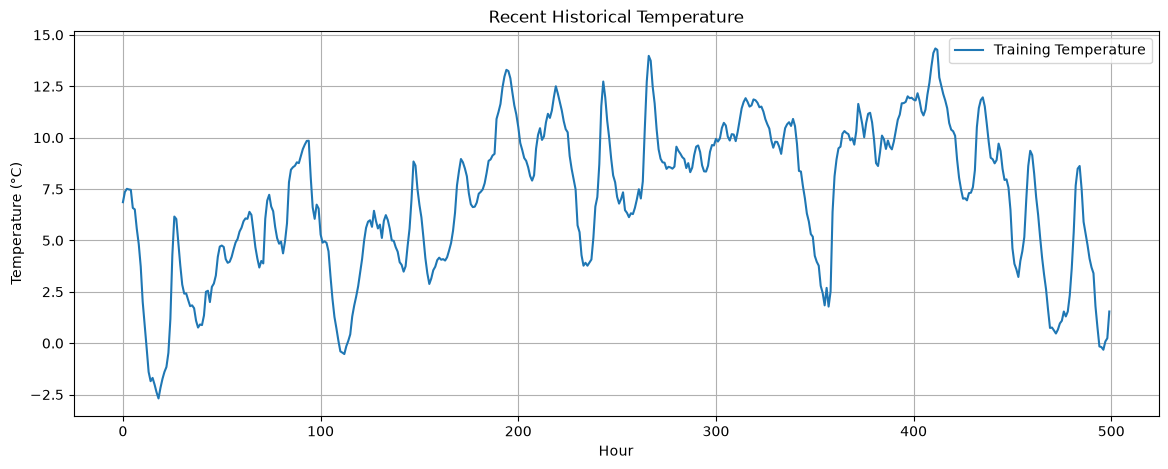

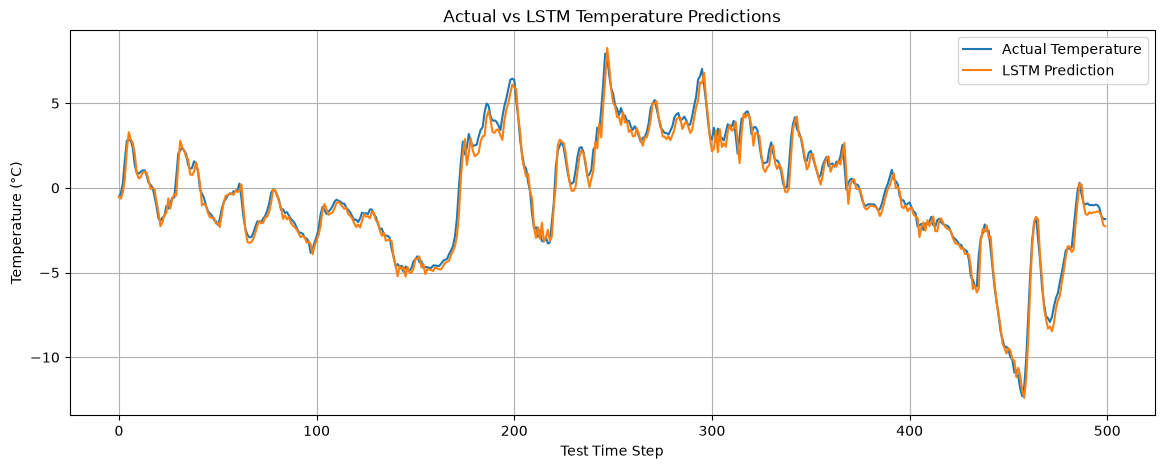

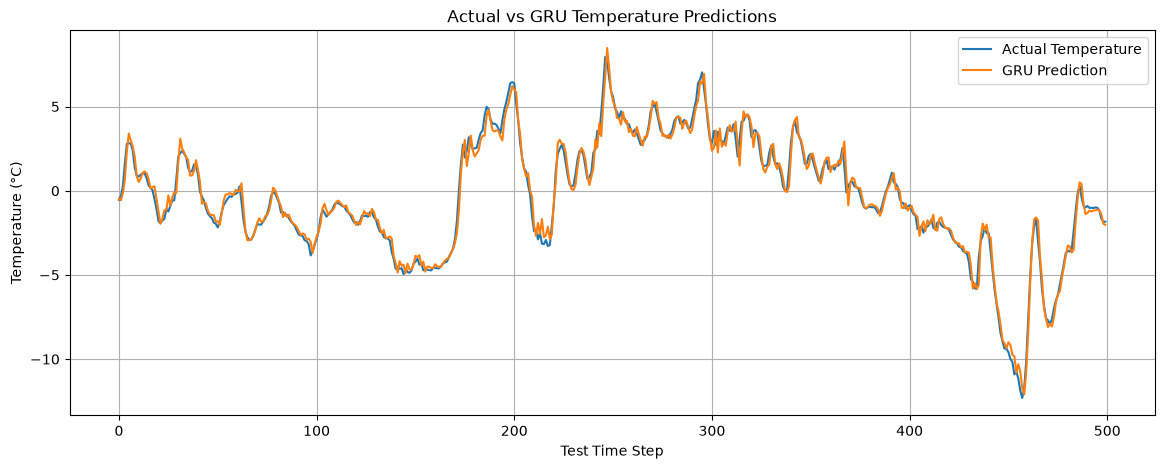

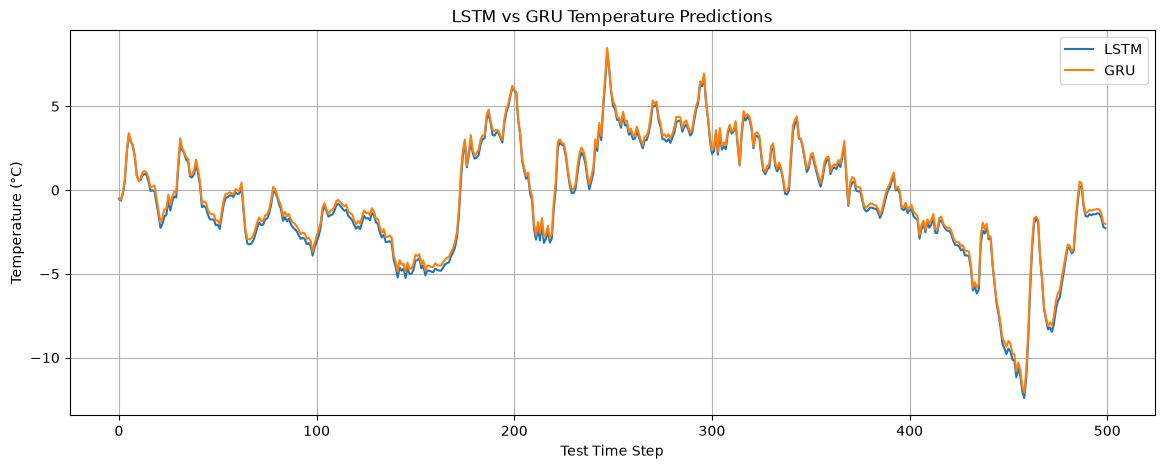

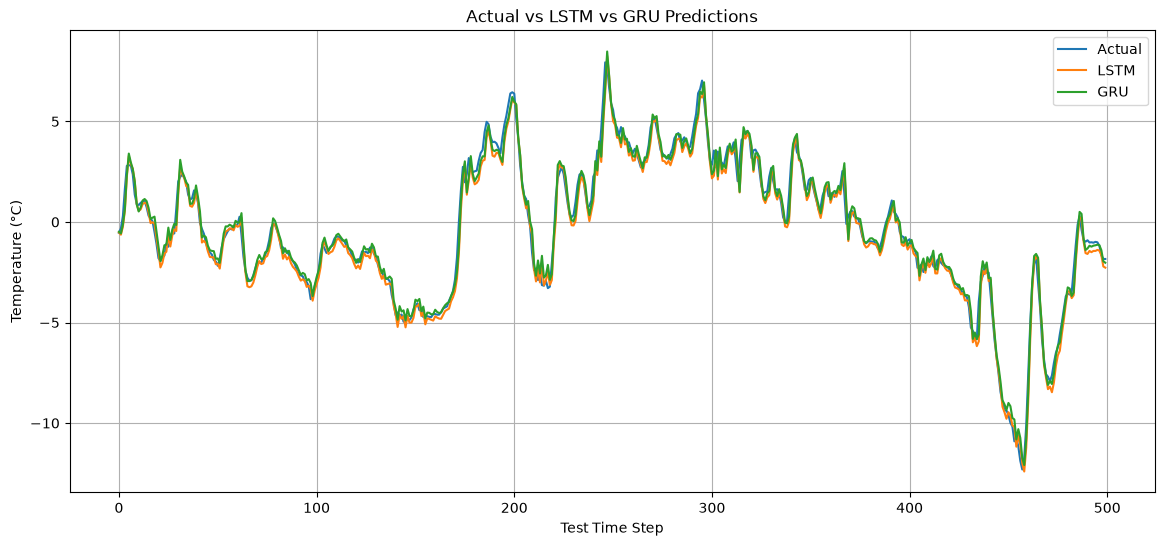

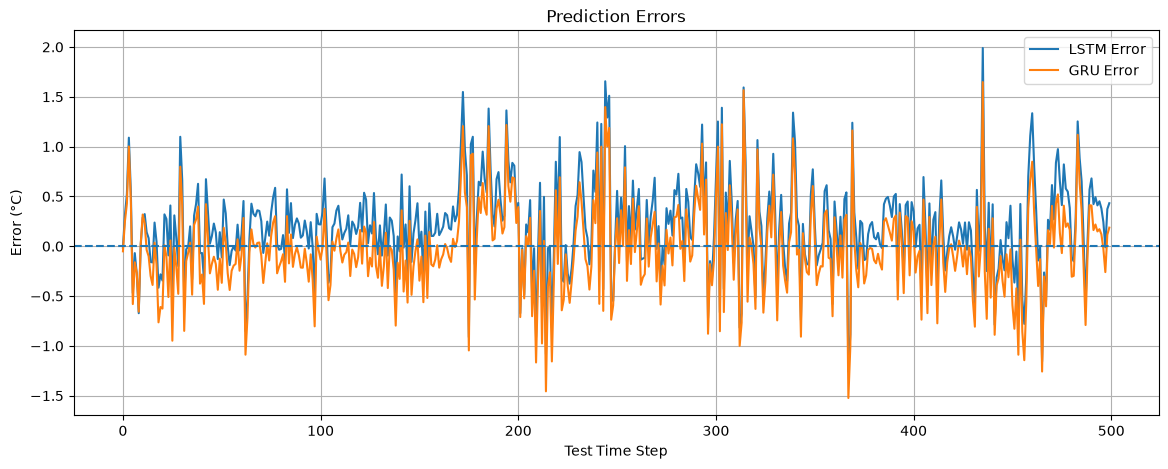

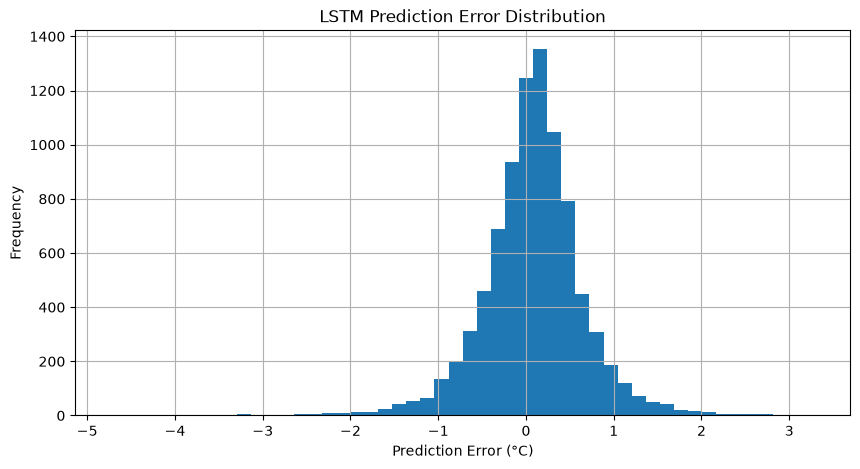

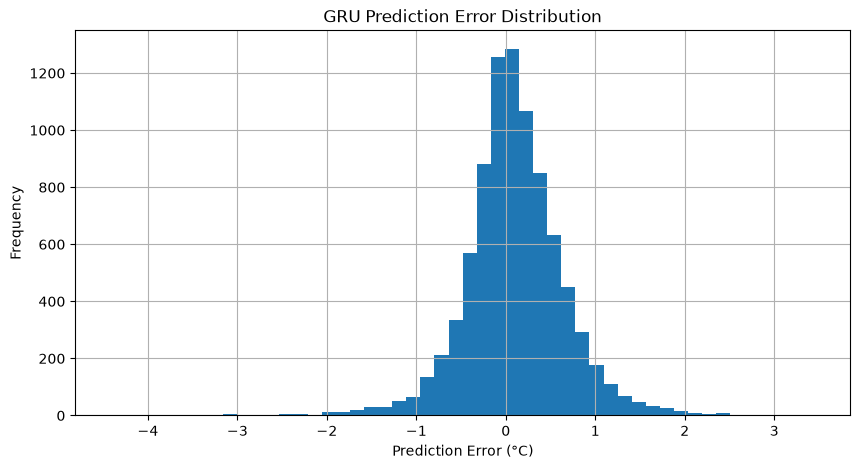

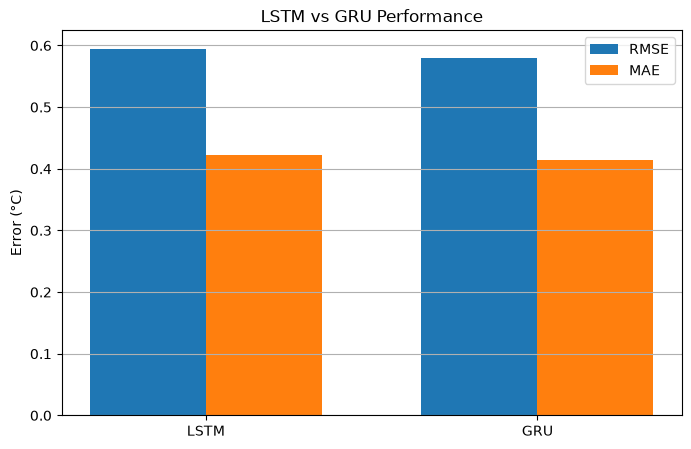

MODEL PERFORMANCE
LSTM RMSE : 0.5947 °C
LSTM MAE  : 0.4231 °C

GRU RMSE  : 0.5804 °C
GRU MAE   : 0.4142 °C


In [4]:
# ============================================================
# VISUALIZATIONS
# Weather Temperature Forecasting using LSTM and GRU
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Temperature History
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    train_df['temperature'].values[-500:],
    label='Training Temperature'
)

plt.title('Recent Historical Temperature')
plt.xlabel('Hour')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 2. Actual vs LSTM Predictions
# ------------------------------------------------------------

# Plot first 500 test samples for readability
plot_size = min(500, len(lstm_predictions))

plt.figure(figsize=(14, 5))

plt.plot(
    y_test_original[:plot_size],
    label='Actual Temperature'
)

plt.plot(
    lstm_predictions[:plot_size],
    label='LSTM Prediction'
)

plt.title('Actual vs LSTM Temperature Predictions')
plt.xlabel('Test Time Step')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 3. Actual vs GRU Predictions
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    y_test_original[:plot_size],
    label='Actual Temperature'
)

plt.plot(
    gru_predictions[:plot_size],
    label='GRU Prediction'
)

plt.title('Actual vs GRU Temperature Predictions')
plt.xlabel('Test Time Step')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 4. LSTM vs GRU Predictions
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    lstm_predictions[:plot_size],
    label='LSTM'
)

plt.plot(
    gru_predictions[:plot_size],
    label='GRU'
)

plt.title('LSTM vs GRU Temperature Predictions')
plt.xlabel('Test Time Step')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 5. Actual vs Both Models
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    y_test_original[:plot_size],
    label='Actual'
)

plt.plot(
    lstm_predictions[:plot_size],
    label='LSTM'
)

plt.plot(
    gru_predictions[:plot_size],
    label='GRU'
)

plt.title('Actual vs LSTM vs GRU Predictions')
plt.xlabel('Test Time Step')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 6. Prediction Errors
# ------------------------------------------------------------

lstm_errors = (
    y_test_original - lstm_predictions
)

gru_errors = (
    y_test_original - gru_predictions
)


plt.figure(figsize=(14, 5))

plt.plot(
    lstm_errors[:plot_size],
    label='LSTM Error'
)

plt.plot(
    gru_errors[:plot_size],
    label='GRU Error'
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title('Prediction Errors')
plt.xlabel('Test Time Step')
plt.ylabel('Error (°C)')
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 7. Error Distribution - LSTM
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.hist(
    lstm_errors,
    bins=50
)

plt.title('LSTM Prediction Error Distribution')
plt.xlabel('Prediction Error (°C)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 8. Error Distribution - GRU
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.hist(
    gru_errors,
    bins=50
)

plt.title('GRU Prediction Error Distribution')
plt.xlabel('Prediction Error (°C)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 9. RMSE and MAE Comparison
# ------------------------------------------------------------

lstm_mae = mean_absolute_error(
    y_test_original,
    lstm_predictions
)

gru_mae = mean_absolute_error(
    y_test_original,
    gru_predictions
)


models = ['LSTM', 'GRU']
rmse_values = [lstm_rmse, gru_rmse]
mae_values = [lstm_mae, gru_mae]


plt.figure(figsize=(8, 5))

x = np.arange(len(models))
width = 0.35

plt.bar(
    x - width / 2,
    rmse_values,
    width,
    label='RMSE'
)

plt.bar(
    x + width / 2,
    mae_values,
    width,
    label='MAE'
)

plt.xticks(
    x,
    models
)

plt.ylabel('Error (°C)')
plt.title('LSTM vs GRU Performance')
plt.legend()
plt.grid(
    axis='y'
)

plt.show()


# ------------------------------------------------------------
# 10. Print Final Metrics
# ------------------------------------------------------------

print("=" * 55)
print("MODEL PERFORMANCE")
print("=" * 55)

print(f"LSTM RMSE : {lstm_rmse:.4f} °C")
print(f"LSTM MAE  : {lstm_mae:.4f} °C")

print()

print(f"GRU RMSE  : {gru_rmse:.4f} °C")
print(f"GRU MAE   : {gru_mae:.4f} °C")

print("=" * 55)

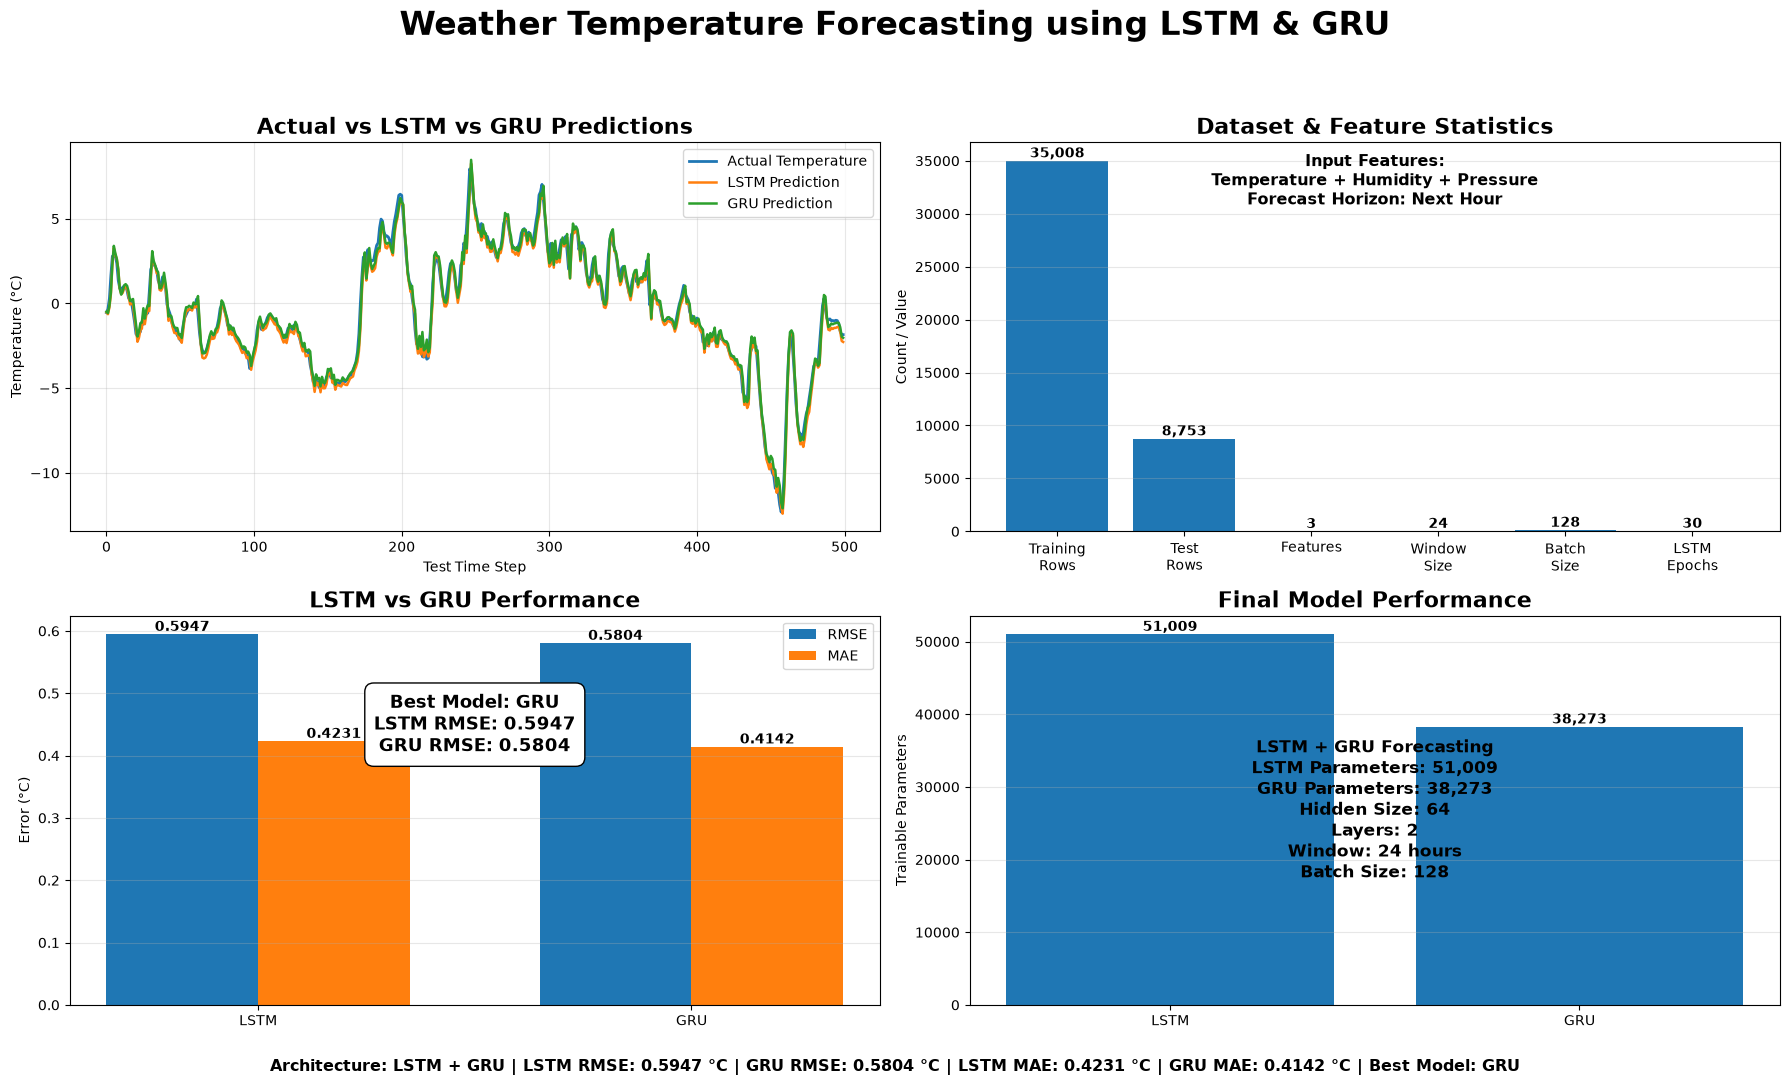

VISUALIZATION SAVED
Weather_LSTM_GRU_Visualization.png


In [5]:
# ============================================================
# FINAL VISUALIZATION DASHBOARD
# Weather Temperature Forecasting using LSTM and GRU
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Parameter statistics
# ------------------------------------------------------------

lstm_total_params = sum(
    p.numel()
    for p in lstm_model.parameters()
)

gru_total_params = sum(
    p.numel()
    for p in gru_model.parameters()
)

lstm_trainable_params = sum(
    p.numel()
    for p in lstm_model.parameters()
    if p.requires_grad
)

gru_trainable_params = sum(
    p.numel()
    for p in gru_model.parameters()
    if p.requires_grad
)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

lstm_mae = mean_absolute_error(
    y_test_original,
    lstm_predictions
)

gru_mae = mean_absolute_error(
    y_test_original,
    gru_predictions
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        lstm_predictions
    )
)

gru_rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        gru_predictions
    )
)

# ------------------------------------------------------------
# Dataset statistics
# ------------------------------------------------------------

train_samples = len(train_df)
test_samples = len(test_df)

number_of_features = (
    train_df.drop(
        columns=["datetime"]
    ).shape[1]
)

window_size = WINDOW_SIZE

# ------------------------------------------------------------
# Plot size
# ------------------------------------------------------------

plot_size = min(
    500,
    len(lstm_predictions)
)

time_axis = np.arange(
    plot_size
)

# ------------------------------------------------------------
# Determine best model
# ------------------------------------------------------------

best_model = (
    "LSTM"
    if lstm_rmse < gru_rmse
    else "GRU"
)

# ------------------------------------------------------------
# Create dashboard
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 11)
)

fig.suptitle(
    "Weather Temperature Forecasting using LSTM & GRU",
    fontsize=24,
    fontweight="bold"
)

# ============================================================
# TOP LEFT
# Actual vs Predictions
# ============================================================

ax = axes[0, 0]

ax.plot(
    time_axis,
    y_test_original[:plot_size],
    linewidth=2,
    label="Actual Temperature"
)

ax.plot(
    time_axis,
    lstm_predictions[:plot_size],
    linewidth=1.8,
    label="LSTM Prediction"
)

ax.plot(
    time_axis,
    gru_predictions[:plot_size],
    linewidth=1.8,
    label="GRU Prediction"
)

ax.set_title(
    "Actual vs LSTM vs GRU Predictions",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Test Time Step")
ax.set_ylabel("Temperature (°C)")

ax.legend()

ax.grid(
    True,
    alpha=0.3
)

# ============================================================
# TOP RIGHT
# Dataset & Feature Statistics
# ============================================================

ax = axes[0, 1]

stats_names = [
    "Training\nRows",
    "Test\nRows",
    "Features",
    "Window\nSize",
    "Batch\nSize",
    "LSTM\nEpochs"
]

stats_values = [
    train_samples,
    test_samples,
    number_of_features,
    window_size,
    batch_size,
    lstm_epochs
]

bars = ax.bar(
    stats_names,
    stats_values
)

ax.set_title(
    "Dataset & Feature Statistics",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Count / Value")

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    stats_values
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.text(
    0.5,
    0.90,
    "Input Features:\n"
    "Temperature + Humidity + Pressure\n"
    "Forecast Horizon: Next Hour",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=11.5,
    fontweight="bold"
)

# ============================================================
# BOTTOM LEFT
# Model Evaluation
# ============================================================

ax = axes[1, 0]

models = [
    "LSTM",
    "GRU"
]

x = np.arange(
    len(models)
)

width = 0.35

rmse_values = [
    lstm_rmse,
    gru_rmse
]

mae_values = [
    lstm_mae,
    gru_mae
]

bars1 = ax.bar(
    x - width / 2,
    rmse_values,
    width,
    label="RMSE"
)

bars2 = ax.bar(
    x + width / 2,
    mae_values,
    width,
    label="MAE"
)

ax.set_title(
    "LSTM vs GRU Performance",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Error (°C)")

ax.set_xticks(
    x
)

ax.set_xticklabels(
    models
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)

for bars in [
    bars1,
    bars2
]:

    for bar in bars:

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{bar.get_height():.4f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

ax.text(
    0.5,
    0.72,
    f"Best Model: {best_model}\n"
    f"LSTM RMSE: {lstm_rmse:.4f}\n"
    f"GRU RMSE: {gru_rmse:.4f}",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="black"
    )
)

# ============================================================
# BOTTOM RIGHT
# Final Model Performance
# ============================================================

ax = axes[1, 1]

# Compare parameter counts

model_names = [
    "LSTM",
    "GRU"
]

parameter_values = [
    lstm_total_params,
    gru_total_params
]

bars = ax.bar(
    model_names,
    parameter_values
)

ax.set_title(
    "Final Model Performance",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Trainable Parameters")

ax.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    parameter_values
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.text(
    0.5,
    0.50,
    "LSTM + GRU Forecasting\n"
    f"LSTM Parameters: {lstm_total_params:,}\n"
    f"GRU Parameters: {gru_total_params:,}\n"
    f"Hidden Size: 64\n"
    f"Layers: 2\n"
    f"Window: {WINDOW_SIZE} hours\n"
    f"Batch Size: {batch_size}",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=12.5,
    fontweight="bold"
)

# ============================================================
# FOOTER
# ============================================================

fig.text(
    0.5,
    0.015,
    f"Architecture: LSTM + GRU | "
    f"LSTM RMSE: {lstm_rmse:.4f} °C | "
    f"GRU RMSE: {gru_rmse:.4f} °C | "
    f"LSTM MAE: {lstm_mae:.4f} °C | "
    f"GRU MAE: {gru_mae:.4f} °C | "
    f"Best Model: {best_model}",
    ha="center",
    fontsize=11.5,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0.04, 1, 0.94]
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

output_file = "Weather_LSTM_GRU_Visualization.png"

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("VISUALIZATION SAVED")
print("=" * 70)
print(output_file)